# 📰 Fake News Detection using BERT
### Complete End-to-End Pipeline — Kaggle Notebook

**Steps covered:**
1. Install & import libraries
2. Load & explore dataset
3. Text cleaning & preprocessing
4. Baseline model (Logistic Regression + TF-IDF)
5. BERT tokenization & DataLoaders
6. Build BERT classifier
7. Train BERT
8. Evaluate (Accuracy, Precision, Recall, F1, Confusion Matrix)
9. Plot training curves
10. Save & load model
11. Predict on new text
12. Model comparison chart

## ✅ Step 1 — Install & Import Libraries

In [3]:
# Install missing packages
!pip install transformers -q
!pip install accelerate -q

In [4]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# ── Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=' * 50)
print(f'  Using device : {device}')
if device.type == 'cuda':
    print(f'  GPU          : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('=' * 50)

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Libraries loaded successfully ✓')

  Using device : cuda
  GPU          : Tesla T4
  VRAM         : 15.6 GB
Libraries loaded successfully ✓


## ✅ Step 2 — Load & Explore Dataset

In [8]:
# ── Auto-detect dataset path ───────────────────────────────────────────────
# Kaggle datasets are mounted at /kaggle/input/
import glob

csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print('CSV files found:')
for f in csv_files:
    print(' ', f)

# Pick the right file
DATA_PATH = None
for f in csv_files:
    name = os.path.basename(f).lower()
    if any(kw in name for kw in ['train', 'fake', 'news']):
        DATA_PATH = f
        break

if DATA_PATH is None and csv_files:
    DATA_PATH = csv_files[0]

print(f'\nUsing: {DATA_PATH}')

CSV files found:
  /kaggle/input/datasets/divyanshrajput3/fakenews/news.csv

Using: /kaggle/input/datasets/divyanshrajput3/fakenews/news.csv


In [9]:
# ── Load dataset ──────────────────────────────────────────────────────────
if DATA_PATH:
    df_raw = pd.read_csv(DATA_PATH)
else:
    # Fallback: generate synthetic data
    print('No dataset found — generating synthetic data...')
    np.random.seed(SEED)
    real_texts = [
        'Scientists confirm climate research shows positive outcomes in peer-reviewed study.',
        'Government officials announced new economic policy following months of review.',
        'University researchers publish findings on vaccine efficacy validating hypothesis.',
        'Federal Reserve raises interest rates amid inflation concerns in global markets.',
        'New medical treatment shows promising results in large-scale clinical trial.',
        'Environmental agency releases data showing air quality improvement nationally.',
        'Independent study confirms safety of approved medications for general use.',
        'Election results certified after thorough review by independent auditors.',
    ]
    fake_texts = [
        'SHOCKING secret documents prove government is hiding alien contact from public!',
        'They dont want you to know big pharma suppressing miracle cancer cure today!',
        'BREAKING deep state caught red-handed stealing election whistleblower reveals!',
        'You wont believe what they found 5G towers actually mind control devices exposed!',
        'WARNING government adding chemicals to water supply to control population now!',
        'EXCLUSIVE leaked files reveal moon landing was staged in Hollywood studio hoax!',
        'Share before deleted world leaders secret society controlling global economy!',
        'Banned video proves vaccines contain microchips for tracking citizens worldwide!',
    ]
    rows = []
    for i in range(2000):
        if i % 2 == 0:
            t = np.random.choice(fake_texts) + f' case {i} details emerged exclusively.'
            rows.append({'title': t, 'text': t, 'label': 0})
        else:
            t = np.random.choice(real_texts) + f' Study number {i} provides new evidence.'
            rows.append({'title': t, 'text': t, 'label': 1})
    df_raw = pd.DataFrame(rows)

print('\nRaw dataframe:')
print(f'  Shape   : {df_raw.shape}')
print(f'  Columns : {df_raw.columns.tolist()}')
df_raw.head(3)


Raw dataframe:
  Shape   : (23196, 7)
  Columns : ['title', 'news_url', 'source_domain', 'tweet_num', 'label', 'text', 'author']


,title,news_url,source_domain,tweet_num,label,text,author
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1,Kandi Burruss Explodes Over Rape Accusation on...,NaN
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1,People's Choice Awards 2018: The best red carp...,NaN
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1,Sophia Bush Sends Sweet Birthday Message to 'O...,NaN


In [10]:
# ── Normalise columns ─────────────────────────────────────────────────────
df = df_raw.copy()
cols_lower = {c: c.lower().strip() for c in df.columns}
df.rename(columns=cols_lower, inplace=True)

# Handle different label column names
for possible_label in ['label', 'real', 'fake', 'class', 'target']:
    if possible_label in df.columns:
        df.rename(columns={possible_label: 'label'}, inplace=True)
        break

# Handle string labels
LABEL2ID = {'FAKE': 0, 'REAL': 1, 'fake': 0, 'real': 1, '0': 0, '1': 1}
ID2LABEL = {0: 'FAKE', 1: 'REAL'}

if df['label'].dtype == object:
    df['label'] = df['label'].str.strip().str.upper().map({'FAKE': 0, 'REAL': 1})
df['label'] = df['label'].astype(int)

# Fill missing text columns
for col in ['title', 'text', 'author']:
    if col not in df.columns:
        df[col] = ''
    df[col] = df[col].fillna('')

print('Label distribution:')
print(df['label'].value_counts().rename(index=ID2LABEL))

Label distribution:
label
REAL    17441
FAKE     5755
Name: count, dtype: int64



  DATASET STATISTICS
  Total samples  : 23,196
  FAKE           :  5,755  (24.8%)
  REAL           : 17,441  (75.2%)


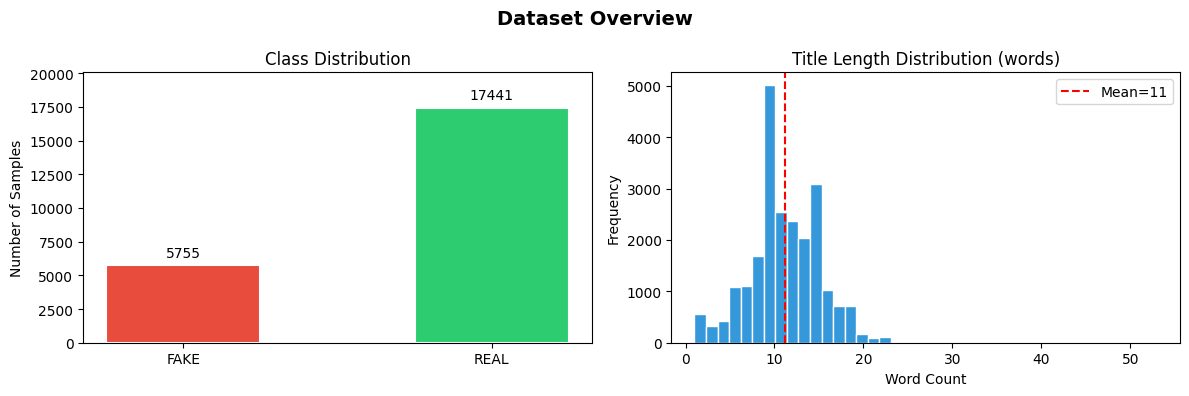

Plot saved ✓


In [11]:
# ── Dataset Statistics & Visualisation ────────────────────────────────────
print('\n' + '='*55)
print('  DATASET STATISTICS')
print('='*55)
print(f'  Total samples  : {len(df):,}')
counts = df['label'].value_counts().sort_index()
for lbl, cnt in counts.items():
    print(f'  {ID2LABEL[lbl]:>4s}           : {cnt:>6,}  ({cnt/len(df)*100:.1f}%)')
print('='*55)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Class distribution
bars = axes[0].bar(
    [ID2LABEL[l] for l in counts.index], counts.values,
    color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5, width=0.5
)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Samples')
axes[0].bar_label(bars, fmt='%d', padding=4)
axes[0].set_ylim(0, counts.max() * 1.15)

# Title length
df['title_len'] = df['title'].str.split().apply(len)
axes[1].hist(df['title_len'], bins=40, color='#3498DB', edgecolor='white')
axes[1].set_title('Title Length Distribution (words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['title_len'].mean(), color='red', linestyle='--',
                 label=f"Mean={df['title_len'].mean():.0f}")
axes[1].legend()
plt.tight_layout()
plt.savefig('dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## ✅ Step 3 — Text Cleaning & Preprocessing

In [12]:
def clean_text(text):
    """
    Cleans raw news text:
      1. Lowercase
      2. Remove URLs
      3. Remove HTML tags
      4. Remove special characters
      5. Collapse whitespace
    """
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)      # URLs
    text = re.sub(r'<[^>]+>', ' ', text)                # HTML tags
    text = re.sub(r"[^a-z0-9\s\.,!?'\-]", ' ', text)  # Special chars
    text = re.sub(r'\s+', ' ', text).strip()            # Whitespace
    return text

# Combine title + text and clean
df['content'] = (df['title'] + ' ' + df['text']).apply(clean_text)

# Drop rows with empty content
df = df[df['content'].str.strip().ne('')].reset_index(drop=True)

# Show sample
print('Before cleaning:')
print(df_raw['title'].iloc[0] if 'title' in df_raw.columns else '')
print('\nAfter cleaning:')
print(df['content'].iloc[0])
print(f'\nFinal dataset shape: {df.shape}')

Before cleaning:
Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video)

After cleaning:
kandi burruss explodes over rape accusation on 'real housewives of atlanta' reunion video kandi burruss explodes over rape accusation on 'real housewives of atlanta' reunion video

Final dataset shape: (23193, 9)


## ✅ Step 4 — Train / Val / Test Split

In [13]:
texts  = df['content'].tolist()
labels = df['label'].tolist()

# 70% train | 15% val | 15% test  (stratified)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    texts, labels, test_size=0.15, stratify=labels, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, stratify=y_tmp, random_state=SEED
)

print(f'Train : {len(X_train):,} samples')
print(f'Val   : {len(X_val):,} samples')
print(f'Test  : {len(X_test):,} samples')

Train : 16,244 samples
Val   : 3,470 samples
Test  : 3,479 samples


## ✅ Step 5 — Baseline: Logistic Regression + TF-IDF

In [14]:
print('Training Logistic Regression baseline...')

baseline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)),
])
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)
baseline_acc   = accuracy_score(y_test, baseline_preds)

print('\n' + '='*55)
print('  BASELINE: Logistic Regression + TF-IDF')
print('='*55)
print(f'  Test Accuracy : {baseline_acc:.4f}')
print()
print(classification_report(y_test, baseline_preds,
                             target_names=['FAKE','REAL'], zero_division=0))
print('='*55)

Training Logistic Regression baseline...

  BASELINE: Logistic Regression + TF-IDF
  Test Accuracy : 0.8425

              precision    recall  f1-score   support

        FAKE       0.81      0.47      0.60       863
        REAL       0.85      0.96      0.90      2616

    accuracy                           0.84      3479
   macro avg       0.83      0.72      0.75      3479
weighted avg       0.84      0.84      0.83      3479



## ✅ Step 6 — BERT Tokenization & PyTorch Dataset

In [15]:
# ── Hyperparameters ───────────────────────────────────────────────────────
MODEL_NAME  = 'bert-base-uncased'
MAX_LEN     = 128      # 128 is faster on Kaggle; use 256 for higher accuracy
BATCH_SIZE  = 32
NUM_EPOCHS  = 3
LR          = 2e-5
WARMUP_RATIO = 0.1
DROPOUT     = 0.3

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size:,} ✓')

Loading tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Vocab size: 30,522 ✓


In [16]:
# ── Show tokenization example ─────────────────────────────────────────────
sample = X_train[0]
enc    = tokenizer(sample, max_length=MAX_LEN, padding='max_length',
                   truncation=True, return_tensors='pt')
print('Example tokenization:')
print(f'  Original text  : {sample[:80]}...')
print(f'  input_ids shape: {enc["input_ids"].shape}')
print(f'  First 10 tokens: {tokenizer.convert_ids_to_tokens(enc["input_ids"][0][:10].tolist())}')
print(f'  Attention mask : {enc["attention_mask"][0][:10].tolist()}')

Example tokenization:
  Original text  : is justin bieber starting up his own church? is justin bieber starting up his ow...
  input_ids shape: torch.Size([1, 128])
  First 10 tokens: ['[CLS]', 'is', 'justin', 'bi', '##eber', 'starting', 'up', 'his', 'own', 'church']
  Attention mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [17]:
# ── PyTorch Dataset ───────────────────────────────────────────────────────
class FakeNewsDataset(Dataset):
    """
    Tokenizes texts on-the-fly and returns:
      input_ids, attention_mask, labels
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length        = self.max_length,
            padding           = 'max_length',
            truncation        = True,
            return_attention_mask = True,
            return_tensors    = 'pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── Build DataLoaders ────────────────────────────────────────────────────
train_ds = FakeNewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = FakeNewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = FakeNewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 508
Val batches   : 109
Test batches  : 109


## ✅ Step 7 — Build BERT Classifier

In [18]:
class BertFakeNewsClassifier(nn.Module):
    """
    Architecture:
      BertModel → [CLS] pooled output (768-d)
        → Dropout
        → Linear(768 → 256) + GELU
        → Dropout
        → Linear(256 → 2)   [FAKE / REAL]
    """
    def __init__(self, model_name, num_labels=2, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        hidden    = self.bert.config.hidden_size   # 768

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )
        # Xavier init for linear layers
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.pooler_output          # [CLS] token → (B, 768)
        return self.classifier(pooled)      # logits → (B, 2)


model = BertFakeNewsClassifier(MODEL_NAME, dropout=DROPOUT).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total:,}')
print(f'Trainable parameters : {trainable:,}')
print('Model built ✓')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Total parameters     : 109,679,618
Trainable parameters : 109,679,618
Model built ✓


## ✅ Step 8 — Training Pipeline

In [19]:
# ── Loss, Optimiser, Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

# Separate weight-decayed params (no decay on bias / LayerNorm)
no_decay = ['bias', 'LayerNorm.weight']
optimizer = torch.optim.AdamW([
    {'params': [p for n,p in model.named_parameters() if not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n,p in model.named_parameters() if     any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
], lr=LR)

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)
print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')

Total training steps : 1524
Warmup steps         : 152


In [20]:
# ── Training & Validation Loop ────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

def run_epoch(model, loader, optimizer, scheduler, criterion, training):
    model.train() if training else model.eval()
    total_loss = correct = total = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            lbls  = batch['labels'].to(device)

            if training:
                optimizer.zero_grad()

            logits = model(ids, mask)
            loss   = criterion(logits, lbls)

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            preds       = logits.argmax(dim=-1)
            correct    += (preds == lbls).sum().item()
            total      += lbls.size(0)
            total_loss += loss.item() * lbls.size(0)

    return total_loss / total, correct / total


print('\n' + '='*60)
print('  TRAINING BERT')
print('='*60)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = run_epoch(model, train_loader, optimizer, scheduler, criterion, True)
    val_loss,   val_acc   = run_epoch(model, val_loader,   optimizer, scheduler, criterion, False)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    flag = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        flag = '  ★ saved'

    print(f'  Epoch {epoch}/{NUM_EPOCHS} [{time.time()-t0:.0f}s]'
          f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}'
          f'  |  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}{flag}')

print('='*60)
print(f'Best val loss: {best_val_loss:.4f}')
print('Training complete ✓')


  TRAINING BERT
  Epoch 1/3 [370s]  train_loss=0.4807  train_acc=0.7775  |  val_loss=0.3528  val_acc=0.8527  ★ saved
  Epoch 2/3 [377s]  train_loss=0.3071  train_acc=0.8775  |  val_loss=0.3432  val_acc=0.8591  ★ saved
  Epoch 3/3 [376s]  train_loss=0.2061  train_acc=0.9226  |  val_loss=0.3885  val_acc=0.8625
Best val loss: 0.3432
Training complete ✓


## ✅ Step 9 — Plot Training Curves

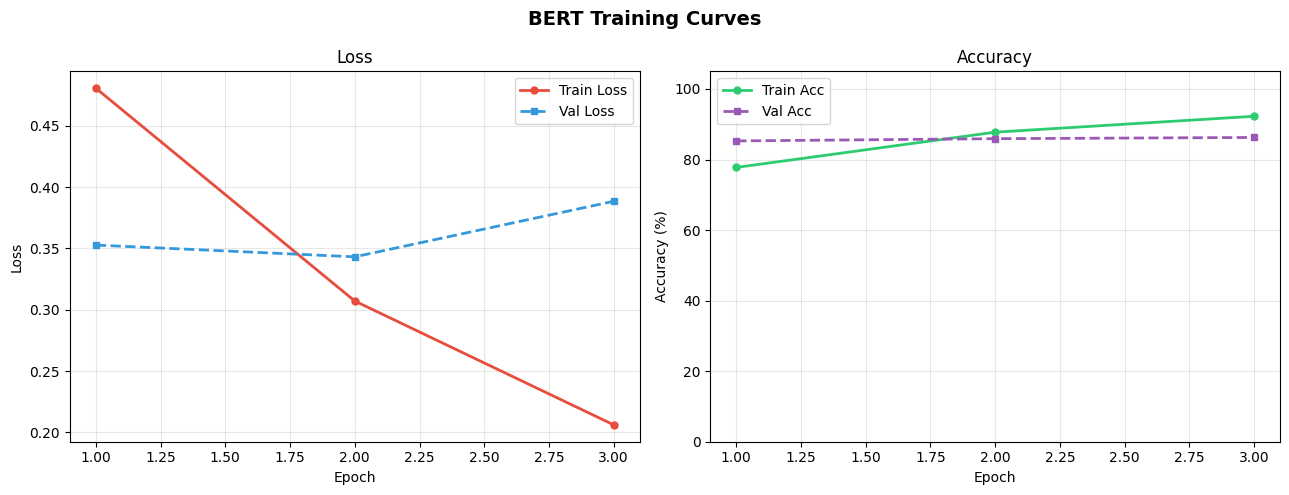

Training curves saved ✓


In [21]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('BERT Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs, history['train_loss'], 'o-', color='#E74C3C', lw=2, ms=5, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   's--',color='#3498DB', lw=2, ms=5, label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, [v*100 for v in history['train_acc']], 'o-', color='#2ECC71', lw=2, ms=5, label='Train Acc')
axes[1].plot(epochs, [v*100 for v in history['val_acc']],   's--',color='#9B59B6', lw=2, ms=5, label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 105); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved ✓')

## ✅ Step 10 — Evaluate on Test Set

In [22]:
# Load best checkpoint
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        lbls  = batch['labels']
        logits = model(ids, mask)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

bert_acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='macro', zero_division=0
)

print('\n' + '='*55)
print('  BERT TEST SET EVALUATION')
print('='*55)
print(f'  Accuracy  : {bert_acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print()
print(classification_report(all_labels, all_preds,
                             target_names=['FAKE','REAL'], zero_division=0))
print('='*55)


  BERT TEST SET EVALUATION
  Accuracy  : 0.8606
  Precision : 0.8508
  Recall    : 0.7547
  F1-Score  : 0.7860

              precision    recall  f1-score   support

        FAKE       0.84      0.54      0.66       863
        REAL       0.87      0.96      0.91      2616

    accuracy                           0.86      3479
   macro avg       0.85      0.75      0.79      3479
weighted avg       0.86      0.86      0.85      3479



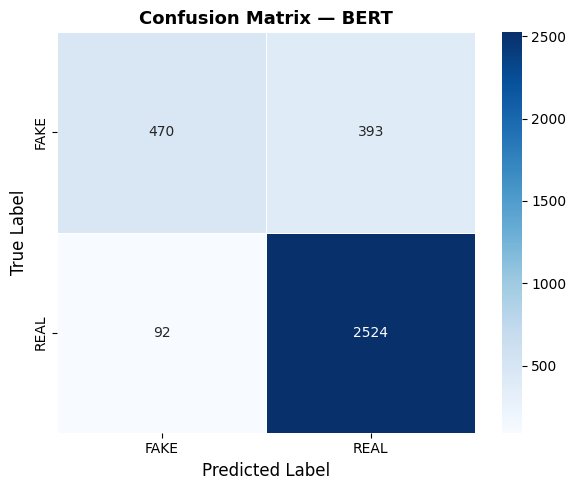

Confusion matrix saved ✓


In [24]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'], yticklabels=['FAKE','REAL'],
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — BERT', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved ✓')

## ✅ Step 11 — Model Comparison Chart

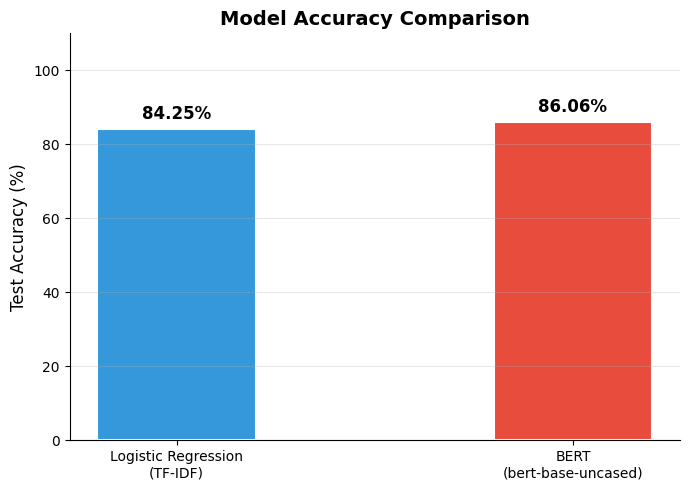

Baseline accuracy : 0.8425
BERT accuracy     : 0.8606
Improvement       : +0.0181


In [25]:
models = ['Logistic Regression\n(TF-IDF)', 'BERT\n(bert-base-uncased)']
accs   = [baseline_acc * 100, bert_acc * 100]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, accs, color=['#3498DB','#E74C3C'],
              width=0.4, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Baseline accuracy : {baseline_acc:.4f}')
print(f'BERT accuracy     : {bert_acc:.4f}')
print(f'Improvement       : +{(bert_acc - baseline_acc):.4f}')

## ✅ Step 12 — predict_news() Function

In [26]:
def predict_news(text, model=model, tokenizer=tokenizer,
                 max_len=MAX_LEN, device=device):
    """
    Predicts whether a news article is REAL or FAKE.

    Parameters
    ----------
    text : str  — Raw news headline or article body

    Returns
    -------
    dict: { label, confidence, probabilities }
    """
    model.eval()
    cleaned  = clean_text(text)
    encoding = tokenizer(
        cleaned,
        max_length = max_len,
        padding    = 'max_length',
        truncation = True,
        return_attention_mask = True,
        return_tensors = 'pt',
    )
    ids  = encoding['input_ids'].to(device)
    mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(ids, mask)
        probs  = torch.softmax(logits, dim=-1).squeeze(0)

    pred_id    = probs.argmax().item()
    confidence = probs[pred_id].item()

    return {
        'label':         ID2LABEL[pred_id],
        'confidence':    round(confidence, 4),
        'probabilities': {
            'FAKE': round(probs[0].item(), 4),
            'REAL': round(probs[1].item(), 4),
        }
    }


# ── Test predictions ──────────────────────────────────────────────────────
samples = [
    'Scientists confirm new vaccine shows 95% efficacy in peer-reviewed clinical trial.',
    'SHOCKING: Government secretly putting chemicals in water supply to control population!',
    'Federal Reserve raises interest rates amid inflation concerns in global markets.',
    'You wont believe what they are hiding! Miracle cure big pharma doesnt want you to know!',
    'NASA confirms successful launch of new Mars exploration rover mission.',
    'BREAKING deep state caught stealing election whistleblower reveals bombshell documents!',
]

print('\n' + '='*65)
print('  LIVE PREDICTIONS')
print('='*65)
for text in samples:
    r    = predict_news(text)
    icon = '✅' if r['label'] == 'REAL' else '🚨'
    print(f'\n  {icon} [{r["label"]}]  confidence={r["confidence"]:.2%}')
    print(f'     FAKE={r["probabilities"]["FAKE"]:.4f}  REAL={r["probabilities"]["REAL"]:.4f}')
    print(f'     "{text[:70]}"')
print('\n' + '='*65)


  LIVE PREDICTIONS

  ✅ [REAL]  confidence=85.90%
     FAKE=0.1410  REAL=0.8590
     "Scientists confirm new vaccine shows 95% efficacy in peer-reviewed cli"

  🚨 [FAKE]  confidence=98.06%
     FAKE=0.9806  REAL=0.0194
     "SHOCKING: Government secretly putting chemicals in water supply to con"

  ✅ [REAL]  confidence=85.45%
     FAKE=0.1455  REAL=0.8545
     "Federal Reserve raises interest rates amid inflation concerns in globa"

  🚨 [FAKE]  confidence=76.34%
     FAKE=0.7634  REAL=0.2366
     "You wont believe what they are hiding! Miracle cure big pharma doesnt "

  ✅ [REAL]  confidence=90.10%
     FAKE=0.0990  REAL=0.9010
     "NASA confirms successful launch of new Mars exploration rover mission."

  🚨 [FAKE]  confidence=96.87%
     FAKE=0.9687  REAL=0.0313
     "BREAKING deep state caught stealing election whistleblower reveals bom"



## ✅ Step 13 — Save Model & Final Summary

In [27]:
# Save model weights + tokenizer
os.makedirs('saved_model', exist_ok=True)
torch.save(model.state_dict(), 'saved_model/bert_fake_news.pt')
tokenizer.save_pretrained('saved_model/tokenizer')
print('Model saved to saved_model/ ✓')

# ── Final Summary ─────────────────────────────────────────────────────────
print('\n' + '█'*55)
print('  FINAL RESULTS SUMMARY')
print('█'*55)
print(f'  Dataset samples       : {len(df):,}')
print(f'  BERT epochs trained   : {NUM_EPOCHS}')
print(f'  Max sequence length   : {MAX_LEN}')
print(f'  Batch size            : {BATCH_SIZE}')
print(f'  Learning rate         : {LR}')
print()
print(f'  Baseline Accuracy     : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)')
print(f'  BERT Accuracy         : {bert_acc:.4f}  ({bert_acc*100:.2f}%)')
print(f'  BERT F1-Score         : {f1:.4f}')
print(f'  Improvement over base : +{(bert_acc-baseline_acc):.4f}')
print()
print('  Output files:')
print('    dataset_stats.png    — class distribution + length histogram')
print('    training_curves.png  — loss & accuracy per epoch')
print('    confusion_matrix.png — BERT test set confusion matrix')
print('    model_comparison.png — BERT vs Logistic Regression')
print('    saved_model/         — model weights + tokenizer')
print('█'*55)

Model saved to saved_model/ ✓

███████████████████████████████████████████████████████
  FINAL RESULTS SUMMARY
███████████████████████████████████████████████████████
  Dataset samples       : 23,193
  BERT epochs trained   : 3
  Max sequence length   : 128
  Batch size            : 32
  Learning rate         : 2e-05

  Baseline Accuracy     : 0.8425  (84.25%)
  BERT Accuracy         : 0.8606  (86.06%)
  BERT F1-Score         : 0.7860
  Improvement over base : +0.0181

  Output files:
    dataset_stats.png    — class distribution + length histogram
    training_curves.png  — loss & accuracy per epoch
    confusion_matrix.png — BERT test set confusion matrix
    model_comparison.png — BERT vs Logistic Regression
    saved_model/         — model weights + tokenizer
███████████████████████████████████████████████████████
